### Baseline Average

--- Analyzing baseline_exact_10runs.csv ---
Extracting scores...

BASELINE STATISTICS (10 RUNS)
   Run_ID  mean        std  count
0       1  83.4  26.561155    100
1       2  82.9  26.715675    100
2       3  84.8  25.365211    100
3       4  84.3  25.554655    100
4       5  84.3  25.554655    100
5       6  83.4  26.561155    100
6       7  84.8  25.365211    100
7       8  84.8  25.365211    100
8       9  85.3  25.164309    100
9      10  84.4  26.220510    100
----------------------------------------
Global Mean Score: 84.24
Run-to-Run Std Dev: 0.7677

Chart saved as baseline_10runs_errorbar.png


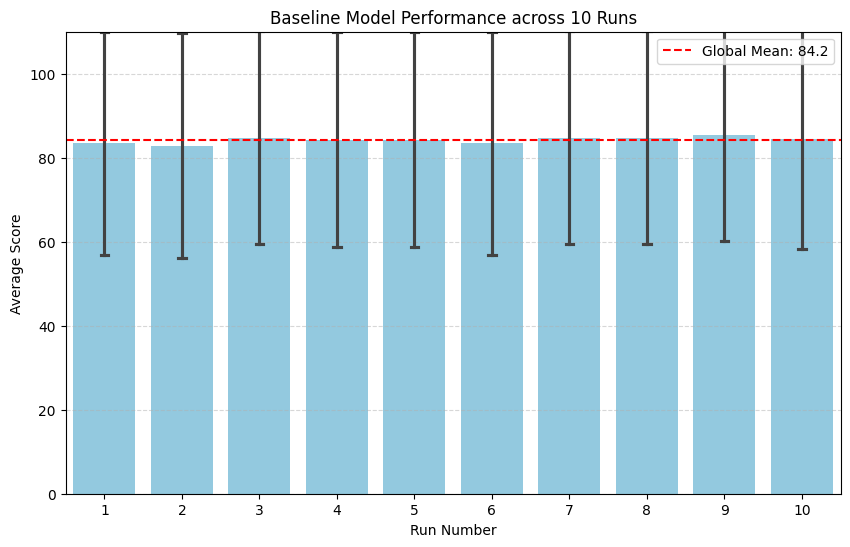

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# --- Configuration ---
# مطمئن شو فایل CSV دقیقاً همین جاست
FILE_PATH = "baseline_exact_10runs.csv"
OUTPUT_IMAGE = "baseline_10runs_errorbar.png"

def extract_score(row):
    """
    استخراج امتیاز با منطق دو مرحله‌ای:
    1. پیدا کردن گزینه (مثلاً Option 1)
    2. پیدا کردن امتیاز آن گزینه در متن سوال
    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. پیدا کردن شماره گزینه (1 یا 2)
        # به دنبال الگوهایی مثل "option 1", "question 1", "choice 2"
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        
        # اگر پیدا نشد، شاید جواب با عدد شروع شده باشد مثل "1."
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            # آخرین گروه پیدا شده معمولاً عدد است
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
            else:
                return None

            # 2. پیدا کردن امتیاز در متن سوال برای آن گزینه
            # به دنبال الگوی: "1. [متن] (100 points)"
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            
            if points_match:
                return int(points_match.group(1))
        
        # 3. روش آخر: جستجوی مستقیم متن (اگر روش گزینه کار نکرد)
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return

    # خواندن فایل
    df = pd.read_csv(FILE_PATH)
    
    # محاسبه امتیاز
    print("Extracting scores...")
    df['Score'] = df.apply(extract_score, axis=1)
    
    # حذف سطرهای نامعتبر
    df_clean = df.dropna(subset=['Score'])
    
    if len(df_clean) == 0:
        print("Error: No scores could be extracted. Check regex logic.")
        return

    # محاسبه آمار برای هر دور (Run)
    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"BASELINE STATISTICS (10 RUNS)")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Mean Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")

    # رسم نمودار
    plt.figure(figsize=(10, 6))
    
    # نمودار میله‌ای با نوار خطا (Standard Deviation)
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='skyblue')
    
    plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Baseline Model Performance across 10 Runs")
    plt.ylabel("Average Score")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

### Core (Money + Reward)

--- Loading Data ---
Extracting scores...

FINAL RESULTS
            Condition   mean        std  count
0  Anhedonic (Lesion)  84.21  25.892979   1000
1   Normal (Baseline)  84.24  25.742671   1000
----------------------------------------
T-Statistic: 0.0260
P-Value: 9.7927e-01
>> CONCLUSION: No significant difference found. (Check layers?)


/tmp/ipykernel_2414523/2853711776.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Score', data=df_clean, errorbar='sd', capsize=.1, palette=['skyblue', 'salmon'])



Final Chart saved as final_comparison_plot.png


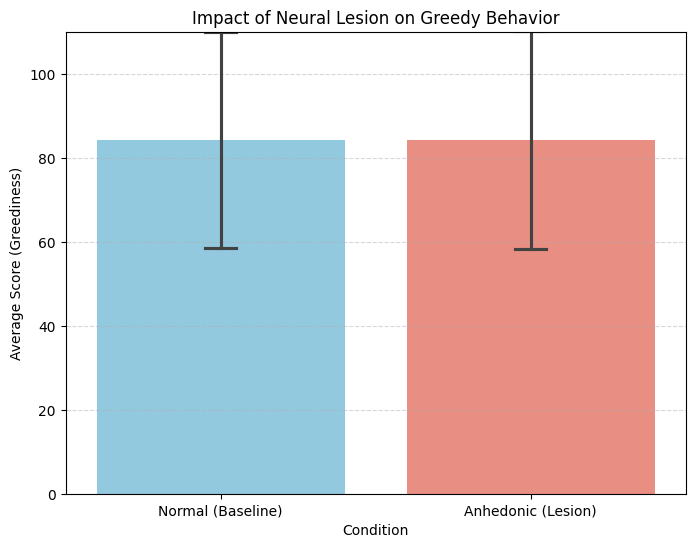

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from scipy.stats import ttest_ind

# --- Configuration ---
BASELINE_FILE = "baseline_exact_10runs.csv"
ANHEDONIC_FILE = "anhedonic_results_10runs.csv"
OUTPUT_IMAGE = "final_comparison_plot.png"

def extract_score(row):
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        
        # 1. Option Search
        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
            selected_num = selection_match.groups()[-1]
            pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
            points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
            if points_match: return int(points_match.group(1))
        
        # 2. Text Search
        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except: return None

def main():
    print("--- Loading Data ---")
    if not os.path.exists(BASELINE_FILE) or not os.path.exists(ANHEDONIC_FILE):
        print("Error: One of the result files is missing.")
        return

    df_base = pd.read_csv(BASELINE_FILE)
    df_anh = pd.read_csv(ANHEDONIC_FILE)
    
    # Labeling
    df_base['Condition'] = 'Normal (Baseline)'
    df_anh['Condition'] = 'Anhedonic (Lesion)'
    
    # Combine
    df_all = pd.concat([df_base, df_anh], ignore_index=True)
    
    print("Extracting scores...")
    df_all['Score'] = df_all.apply(extract_score, axis=1)
    df_clean = df_all.dropna(subset=['Score'])
    
    # --- Statistics ---
    stats = df_clean.groupby('Condition')['Score'].agg(['mean', 'std', 'count']).reset_index()
    print("\n" + "="*40)
    print("FINAL RESULTS")
    print("="*40)
    print(stats)
    print("-" * 40)
    
    # Statistical Significance (T-Test)
    scores_base = df_clean[df_clean['Condition']=='Normal (Baseline)']['Score']
    scores_anh = df_clean[df_clean['Condition']=='Anhedonic (Lesion)']['Score']
    
    t_stat, p_val = ttest_ind(scores_base, scores_anh, equal_var=False)
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value: {p_val:.4e}")
    
    if p_val < 0.05:
        print(">> CONCLUSION: The difference is STATISTICALLY SIGNIFICANT. (Success!)")
    else:
        print(">> CONCLUSION: No significant difference found. (Check layers?)")

    # --- Plotting ---
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Condition', y='Score', data=df_clean, errorbar='sd', capsize=.1, palette=['skyblue', 'salmon'])
    
    plt.title("Impact of Neural Lesion on Greedy Behavior")
    plt.ylabel("Average Score (Greediness)")
    plt.ylim(0, 110)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nFinal Chart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

--- Analyzing anhedonic_results_10runs.csv ---
Extracting scores using robust logic...

ANHEDONIC (LESION) STATISTICS
   Run_ID  mean        std  count
0       1  84.8  25.365211    100
1       2  83.9  26.396166    100
2       3  83.9  26.396166    100
3       4  83.9  26.396166    100
4       5  83.9  26.396166    100
5       6  84.8  25.365211    100
6       7  84.8  25.365211    100
7       8  85.3  25.164309    100
8       9  83.9  26.396166    100
9      10  82.9  26.715675    100
----------------------------------------
Global Anhedonic Score: 84.21
Run-to-Run Std Dev: 0.7015

Chart saved as anhedonic_10runs_performance.png


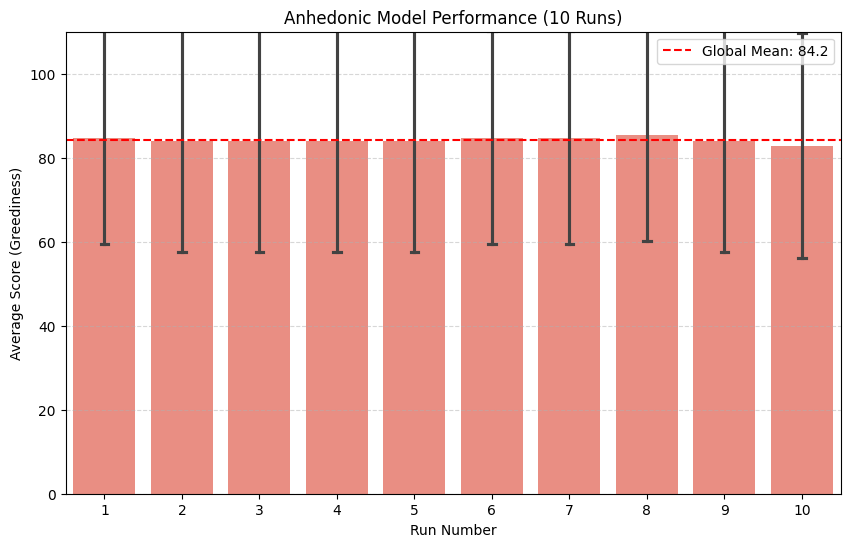

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import numpy as np

# --- Configuration ---
FILE_PATH = "anhedonic_results_10runs.csv"
OUTPUT_IMAGE = "anhedonic_10runs_performance.png"

def extract_score(row):
    """

    """
    try:
        prompt = str(row['Full_Prompt'])
        response = str(row['Model_Response']).lower()
        

        selection_match = re.search(r'(question|option|choice)\s*(?:is\s*)?(\d)', response)
        if not selection_match:
             selection_match = re.search(r'^\s*(\d)\s*[.)]', response)

        if selection_match:
       
            if len(selection_match.groups()) > 0:
                selected_num = selection_match.groups()[-1]
                
 
                pattern = f"{selected_num}\\..*?\\((\\d+)\\s*points?\\)"
                points_match = re.search(pattern, prompt, re.IGNORECASE | re.DOTALL)
                
                if points_match:
                    return int(points_match.group(1))
        

        if "100 point" in response: return 100
        if "50 point" in response: return 50
        if "10 point" in response: return 10
        if "1 point" in response: return 1
            
        return None
    except Exception:
        return None

def main():
    print(f"--- Analyzing {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print(f"Error: {FILE_PATH} not found.")
        return


    df = pd.read_csv(FILE_PATH)
    

    print("Extracting scores using robust logic...")
    df['Score'] = df.apply(extract_score, axis=1)
    

    df_clean = df.dropna(subset=['Score'])
    

    run_stats = df_clean.groupby('Run_ID')['Score'].agg(['mean', 'std', 'count']).reset_index()
    
    print("\n" + "="*40)
    print(f"ANHEDONIC (LESION) STATISTICS")
    print("="*40)
    print(run_stats)
    print("-" * 40)
    
    overall_mean = df_clean['Score'].mean()
    overall_std = run_stats['mean'].std()
    
    print(f"Global Anhedonic Score: {overall_mean:.2f}")
    print(f"Run-to-Run Std Dev: {overall_std:.4f}")
    

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Run_ID', y='Score', data=df_clean, errorbar='sd', capsize=.1, color='salmon')
    
    plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Global Mean: {overall_mean:.1f}')
    
    plt.title("Anhedonic Model Performance (10 Runs)")
    plt.ylabel("Average Score (Greediness)")
    plt.xlabel("Run Number")
    plt.ylim(0, 110)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(OUTPUT_IMAGE)
    print(f"\nChart saved as {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()